
# TBR Usage

In this example, we have multiple treated units. There are two approaches in the panel_exp package.

1. Pre-aggregate the treated units.
2. Model the treated units seperately.


In [1]:
from panel_exp.panel_data import long_df_to_paneldataset, PanelDataset, TimePeriod
from panel_exp.methods.tbr import TBR, TBRRidge
import pandas as pd

# Below we will create a PanelDataset and pretent Nebraska is also treated.
# Additionally, we will pre-aggregate the data. 

long_df = pd.read_csv('kansas_parsed.csv')
long_df.columns = ['un', 'value', 'treated', 'fips', 'time_unit', 'unit']
wide = pd.pivot_table(long_df, columns='time_unit', index='unit', values = 'value', aggfunc=sum, fill_value=0)
treated = ['Kansas', 'Nebraska']

# Pre-Aggregate
control_units = pd.DataFrame(wide.loc[[c for c in wide.index if c not in treated]].mean(axis=0), columns=['controls']).T
treated_units = pd.DataFrame(wide.loc[treated].mean(axis=0), columns=['treated']).T

wide_agg = pd.concat([treated_units, control_units])
panel_data = PanelDataset(wide_agg, treated_units = ['treated'], treated_periods=[TimePeriod(start=2012)])


print(panel_data.summarize())

tbr = TBR(inference='Conformal')
tbr.run_analysis(panel_data)


/Users/christopherb/opt/anaconda3/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/cd/dfrqgp4s4ll55cwb7rtgccbw0000gq/T/ipykernel_32729/169768189.py:10: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  wide = pd.pivot_table(long_df, columns='time_unit', index='unit', values = 'value', aggfunc=sum, fill_value=0)



        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 2
        Number of treated units: 1
        Treated units: ['treated']
        Treated periods: [TimePeriod(start=2012, end=None)]
        


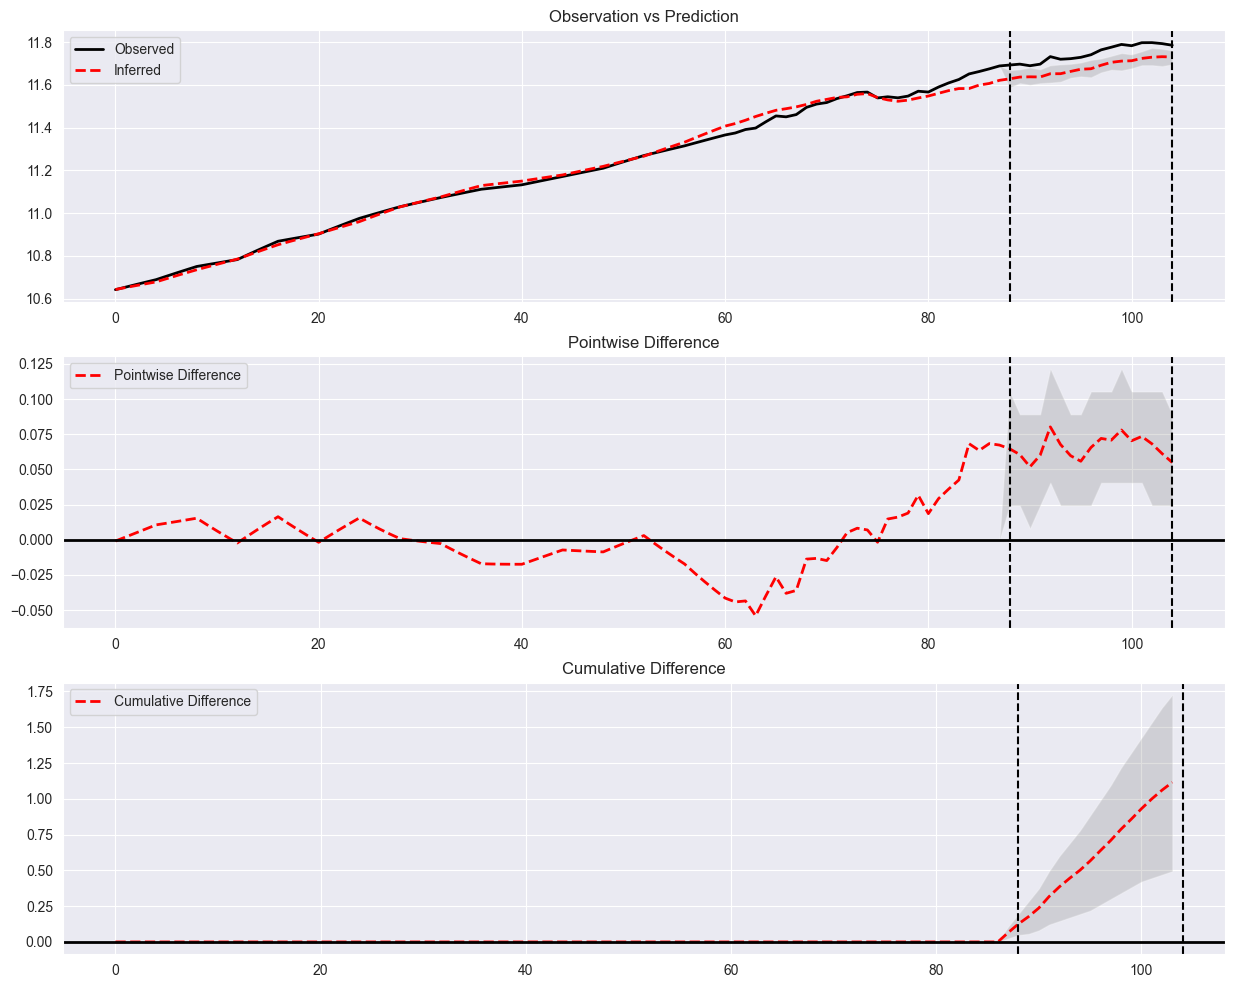

In [2]:
tbr.plot()



In [3]:
# Now keeping them dis-aggregated.
panel_data = long_df_to_paneldataset(long_df, "time_unit", "unit", "value", ["Kansas", "Nebraska"],[2012, 2012])

print(panel_data.summarize())




        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 50
        Number of treated units: 2
        Treated units: ['Kansas', 'Nebraska']
        Treated periods: [TimePeriod(start=2012, end=None), TimePeriod(start=2012, end=None)]
        


In [4]:
tbr = TBRRidge(inference='Conformal')
tbr.run_analysis(panel_data)


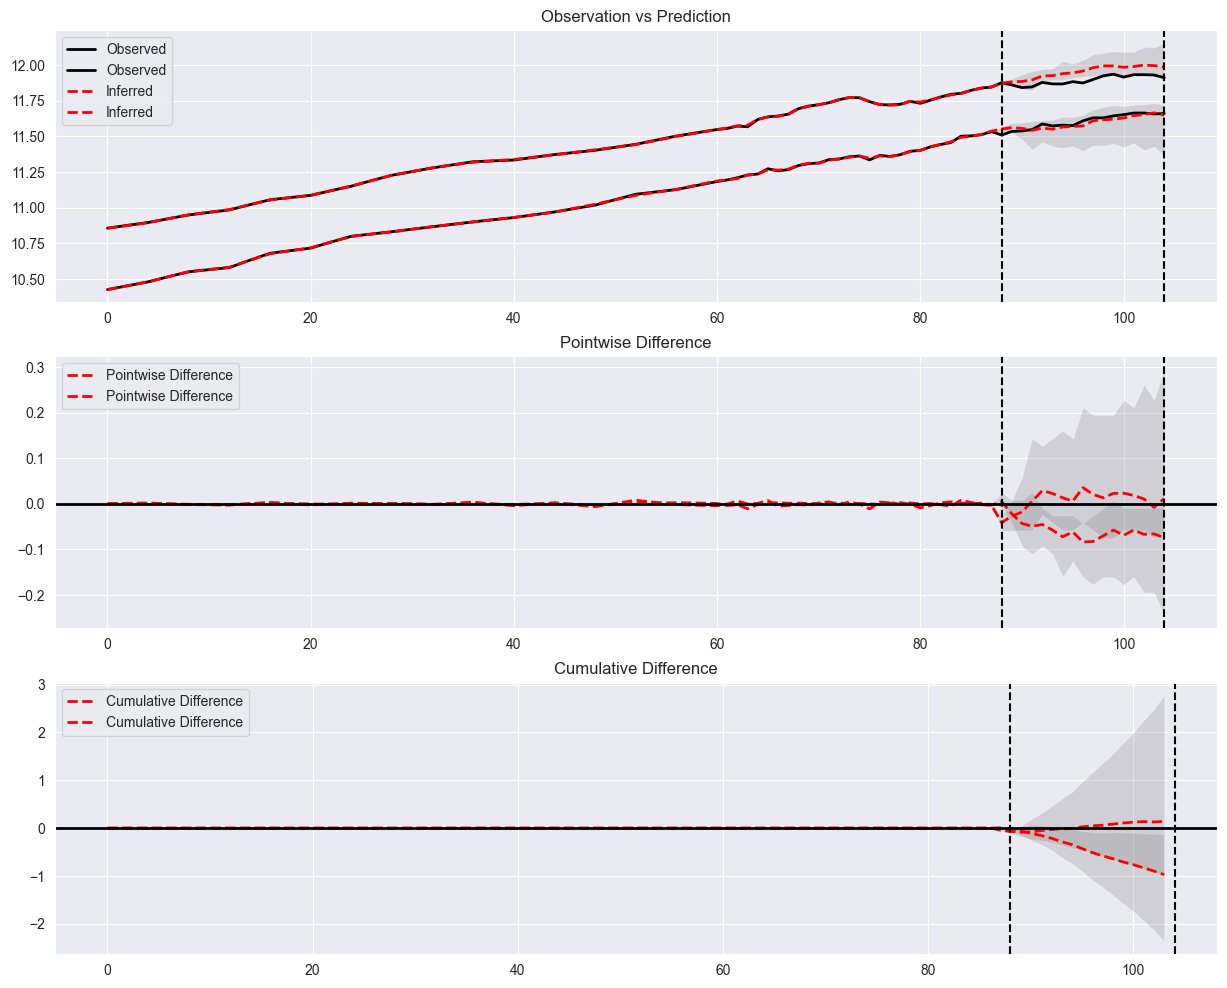

In [5]:
tbr.plot()